In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
# Estandarizamos las columnas numéricas restando la media y dividiendo por la desviación
# para que todas las variables tengan la misma escala y el modelo aprenda mejor
def estandarizacion(X):
    mu = X.mean()
    sigma = X.std(ddof=0)
    sigma = sigma.replace(0, 1)
    X_std = (X - mu) / sigma
    return X_std, mu, sigma

In [31]:
# Calculamos el "coste" (error) actual sumando los errores al cuadrado de nuestras
# predicciones respecto a la realidad. Si esto baja, el modelo mejora
def calcular_coste(X, y, theta):
    m = y.shape[0]
    predictions = X.dot(theta)
    sq_errors = (predictions - y) ** 2
    return (1 / (2 * m)) * np.sum(sq_errors)

In [32]:
# Ejecutamos el algoritmo de optimización: en cada iteración ajustamos un poco
# los pesos (theta) en la dirección opuesta al error para encontrar el mínimo
def descenso_gradiente(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    J_history = np.zeros(num_iters)
    for i in range(num_iters):
        error = X.dot(theta) - y
        grad = (1 / m) * (X.T.dot(error))
        theta = theta - alpha * grad
        J_history[i] = calcular_coste(X, y, theta)
    return theta, J_history

In [33]:
# Calculamos los parámetros óptimos matemáticamente de una sola vez (sin iterar)
# usando álgebra matricial y una pequeña regularización para estabilidad
def ecuacion_normal(X, y):
    XtX = X.T.dot(X)
    reg = 1e-8 * np.eye(XtX.shape[0])
    theta = np.linalg.pinv(XtX + reg).dot(X.T).dot(y)
    return theta


In [34]:
# Barajamos los datos y los cortamos en dos grupos (entrenamiento y test)
# para poder evaluar nuestro modelo con datos que nunca ha visto
def dividir_entrenamiento_test(X, y, test_size=0.2, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    m = X.shape[0]
    indices = np.arange(m)
    np.random.shuffle(indices)
    split = int(np.floor((1 - test_size) * m))
    train_idx = indices[:split]
    test_idx = indices[split:]
    X_train = X.iloc[train_idx].reset_index(drop=True) if isinstance(X, pd.DataFrame) else X[train_idx]
    X_test = X.iloc[test_idx].reset_index(drop=True) if isinstance(X, pd.DataFrame) else X[test_idx]
    y_train = y.iloc[train_idx].reset_index(drop=True) if isinstance(y, pd.DataFrame) else y[train_idx]
    y_test = y.iloc[test_idx].reset_index(drop=True) if isinstance(y, pd.DataFrame) else y[test_idx]
    return X_train, X_test, y_train, y_test

In [35]:
# Definimos métricas estándar (MSE, MAE, MAPE) para cuantificar numéricamente
# cuánto se equivoca nuestro modelo en promedio
def MSE(y_true, y_pred):
    y_true = np.array(y_true).reshape(-1,1)
    y_pred = np.array(y_pred).reshape(-1,1)
    return float(np.mean((y_true - y_pred)**2))

def MAE(y_true, y_pred):
    y_true = np.array(y_true).reshape(-1,1)
    y_pred = np.array(y_pred).reshape(-1,1)
    return float(np.mean(np.abs(y_true - y_pred)))

def MAPE(y_true, y_pred):
    y_true = np.array(y_true).reshape(-1,1)
    y_pred = np.array(y_pred).reshape(-1,1)
    denom = np.where(np.abs(y_true) < 1e-8, 1e-8, np.abs(y_true))
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

In [36]:
# Cargamos el CSV, limpiamos columnas inútiles y traducimos los textos a números
# para que las matemáticas funcionen
def cargar_y_procesar(csv_path, target_col='Coffee_Intake'):
    df = pd.read_csv(csv_path, keep_default_na=False)
    
    mappings = {
        'Sleep_Quality': {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3},
        'Stress_Level':  {'Low': 0, 'Medium': 1, 'High': 2},
        'Alcohol_Consumption': {'Low': 0, 'Moderate': 1, 'High': 2, 'None': 0},
        'Health_Issues': {'None': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
    }
    
    for col, mapping in mappings.items():
        if col in df.columns:
            df[col] = df[col].map(mapping).fillna(0)

    if 'Occupation' in df.columns:
        df = df.drop(columns=['Occupation'])

    cols_num = [
        'Age', 
        'Sleep_Hours', 
        'BMI', 
        'Heart_Rate', 
        'Physical_Activity_Hours', 
        'Smoking',             
        'Alcohol_Consumption', 
        'Sleep_Quality',       
        'Stress_Level',
        'Health_Issues' 
    ]
    
    cols_cat = ['Gender', 'Country']
    
    actual_cols_num = [c for c in cols_num if c in df.columns]
    X_num = df[actual_cols_num].copy()
    
    X_ohe = pd.get_dummies(df[cols_cat], drop_first=True)
    
    for col in X_num.columns:
        X_num[col] = pd.to_numeric(X_num[col], errors='coerce')
        
    X_num = X_num.fillna(X_num.mean())
    X_ohe = X_ohe.fillna(0)
    
    y = df[[target_col]].copy()
    
    return df, X_num, X_ohe, y, actual_cols_num, X_ohe.columns.tolist()

In [37]:
# Construimos la matriz final juntando numéricas estandarizadas, categóricas (One-Hot)
# y añadiendo una columna de unos (bias) para el término independiente
def preparar_matriz_final(X_num, X_ohe, mu=None, sigma=None):
    if mu is None or sigma is None:
        X_num_std, mu, sigma = estandarizacion(X_num)
    else:
        sigma_safe = sigma.replace(0,1)
        X_num_std = (X_num - mu)/sigma_safe
    X_design = pd.concat([X_num_std.reset_index(drop=True), X_ohe.reset_index(drop=True)], axis=1)
    X_design.insert(0,'ones',1)
    return X_design, mu, sigma

In [38]:
# Calculamos R2 para saber qué porcentaje de la varianza explica nuestro modelo
def calcular_r2(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0: return 0.0
    return 1 - (ss_res / ss_tot)


--- Dimensiones ---
Train: (8000, 32), Test: (2000, 32)

Coste inicial (train) con theta cero: 4.222896875000001
Theta (GD) primeros 5 valores:
 [ 2.40347975e+00 -3.00356405e-02 -2.54946598e-01  1.87796230e-03
  7.15281360e-02]


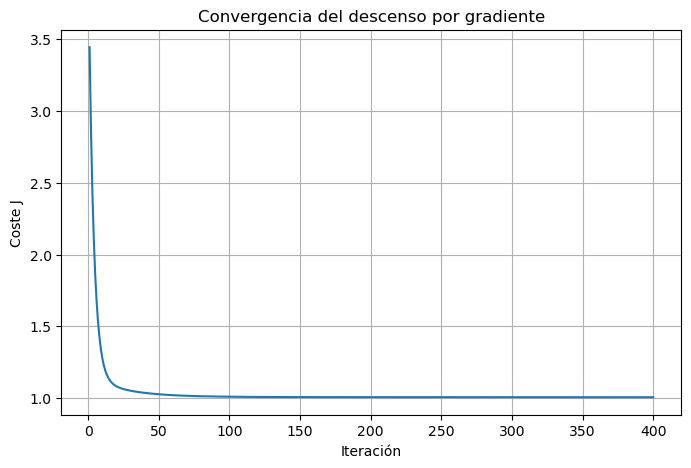


--- Métricas (test set) ---
Descenso por gradiente: MSE=2.0547, MAE=1.1545, MAPE=1427809923.00%
Ecuación normal:        MSE=2.0580, MAE=1.1550, MAPE=1427676445.03%


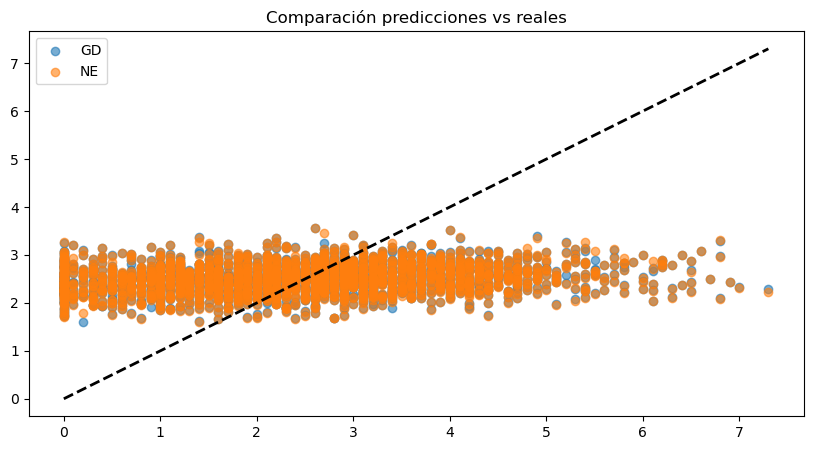


Predicción para el nuevo ejemplo:
 -> Descenso por gradiente: 2.52
 -> Ecuación normal:        2.51

Proceso finalizado.


In [39]:
if __name__ == "__main__":
    csv_path = 'synthetic_coffee_health_10000.csv'
    test_size = 0.2
    random_state = 42
    # Modificación 3
    alpha = 0.1 
    # Modificación 5
    num_iters = 400 
    
    # Cargamos y preparamos los datos, dividiendo primero en Train/Test para
    # evitar fugas de información (data leakage
    df, X_num, X_ohe, y, cols_num, cols_ohe = cargar_y_procesar(csv_path)

    X_raw_completo = pd.concat([X_num, X_ohe], axis=1)
    
    X_train_raw, X_test_raw, y_train_df, y_test_df = dividir_entrenamiento_test(
        X_raw_completo, y, test_size=test_size, random_state=random_state
    )
    
    X_train_num = X_train_raw[cols_num]
    X_train_ohe = X_train_raw.drop(columns=cols_num)
    
    X_test_num = X_test_raw[cols_num]
    X_test_ohe = X_test_raw.drop(columns=cols_num)

    # Estandarizamos usando solo la media/desviación de Train y aplicamos eso a Test
    X_train_design, mu_train, sigma_train = preparar_matriz_final(X_train_num, X_train_ohe)
    X_test_design, _, _ = preparar_matriz_final(X_test_num, X_test_ohe, mu=mu_train, sigma=sigma_train)

    print("\n--- Dimensiones ---")
    print(f"Train: {X_train_design.shape}, Test: {X_test_design.shape}")

    X_train = X_train_design.values.astype(float)
    X_test = X_test_design.values.astype(float)
    y_train = y_train_df.values.astype(float)
    y_test = y_test_df.values.astype(float)
    
    mu = mu_train
    sigma = sigma_train

    # Entrenamos el modelo usando Descenso por Gradiente y visualizamos la convergencia
    # Modificación 4

    # CASO I: Todos los valores = 0
    theta_init = np.zeros((X_train.shape[1],1)) 
    
    # CASO II: Valores pequeños aleatorios
    # theta_init = np.random.uniform(-0.1, 0.1, size=(X_train.shape[1], 1))

    # CASO III: Valores grandes aleatorios
    # theta_init = np.random.uniform(-10, 10, size=(X_train.shape[1], 1))
    
    print("\nCoste inicial (train) con theta cero:", calcular_coste(X_train, y_train, theta_init))
    theta_gd, J_history = descenso_gradiente(X_train, y_train, theta_init, alpha, num_iters)
    print("Theta (GD) primeros 5 valores:\n", theta_gd.flatten()[:5])
    
    plt.figure(figsize=(8,5))
    plt.plot(np.arange(1,num_iters+1), J_history)
    plt.xlabel('Iteración')
    plt.ylabel('Coste J')
    plt.title('Convergencia del descenso por gradiente')
    plt.grid(True)
    plt.show()
    
    # Comparamos con la Ecuación Normal para validar nuestros resultados.
    theta_ne = ecuacion_normal(X_train, y_train)
    
    y_pred_gd = X_test.dot(theta_gd)
    y_pred_ne = X_test.dot(theta_ne)

    # Calculamos métricas finales sobre el conjunto de Test
    mse_gd = MSE(y_test, y_pred_gd)
    mae_gd = MAE(y_test, y_pred_gd)
    mape_gd = MAPE(y_test, y_pred_gd)
    
    mse_ne = MSE(y_test, y_pred_ne)
    mae_ne = MAE(y_test, y_pred_ne)
    mape_ne = MAPE(y_test, y_pred_ne)
    
    print("\n--- Métricas (test set) ---")
    print(f"Descenso por gradiente: MSE={mse_gd:.4f}, MAE={mae_gd:.4f}, MAPE={mape_gd:.2f}%")
    print(f"Ecuación normal:        MSE={mse_ne:.4f}, MAE={mae_ne:.4f}, MAPE={mape_ne:.2f}%")
    
    comp = pd.DataFrame({
        'Metodo':['GradientDescent','NormalEquation'],
        'MSE':[mse_gd,mse_ne],
        'MAE':[mae_gd,mae_ne],
        'MAPE (%)':[mape_gd,mape_ne]
    })
    
    plt.figure(figsize=(10,5))
    plt.scatter(y_test, y_pred_gd, label='GD', alpha=0.6)
    plt.scatter(y_test, y_pred_ne, label='NE', alpha=0.6)
    plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'k--',lw=2)
    plt.title('Comparación predicciones vs reales')
    plt.legend()
    plt.show()
    
    # Probamos el modelo prediciendo un caso nuevo inventado
    mappings_local = {
        'Sleep_Quality': {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3},
        'Stress_Level':  {'Low': 0, 'Medium': 1, 'High': 2},
        'Alcohol_Consumption': {'Low': 0, 'Moderate': 1, 'High': 2, 'None': 0},
        'Health_Issues': {'None': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
    }

    nuevo_raw = {
        'Age':40, 
        'Caffeine_mg':300, 
        'Sleep_Hours':6, 
        'BMI':24, 
        'Heart_Rate':70,
        'Physical_Activity_Hours':8, 
        'Smoking':0, 
        'Alcohol_Consumption':1, 
        'Gender':'Male', 
        'Country':'Germany', 
        'Sleep_Quality':'Good', 
        'Stress_Level':'High',
        'Health_Issues': 'None' 
    }
    
    nuevo_processed = nuevo_raw.copy()
    for col, mapping in mappings_local.items():
        if col in nuevo_processed and isinstance(nuevo_processed[col], str):
             nuevo_processed[col] = mapping.get(nuevo_processed[col], 0)
        elif col in nuevo_processed and isinstance(nuevo_processed[col], (int, float)):
             pass 

    sigma_safe = sigma.replace(0, 1)
    
    x_num = []
    for col in cols_num:
        val = nuevo_processed.get(col, 0) 
        x_std = (val - mu[col]) / sigma_safe[col]
        x_num.append(x_std)
    
    x_ohe = []
    for col in cols_ohe:
        base, val = col.rsplit('_', 1)
        val_input = str(nuevo_raw.get(base, ''))
        x_ohe.append(1 if val_input == val else 0)
    
    x_input = np.array([1] + x_num + x_ohe).reshape(1,-1)
    
    pred_new_gd = x_input.dot(theta_gd)[0,0]
    pred_new_ne = x_input.dot(theta_ne)[0,0]
    
    print("\nPredicción para el nuevo ejemplo:")
    print(f" -> Descenso por gradiente: {pred_new_gd:.2f}")
    print(f" -> Ecuación normal:        {pred_new_ne:.2f}")
    
    comp.to_csv("comparativa_modelos_regresion.csv", index=False)
    print("\nProceso finalizado.")


 INICIO MODIFICACIÓN 1: ANÁLISIS UNIVARIABLE
  -> Analizando variable: Sleep_Hours...
  -> Analizando variable: Stress_Level...
  -> Analizando variable: Age...
  -> Analizando variable: Heart_Rate...


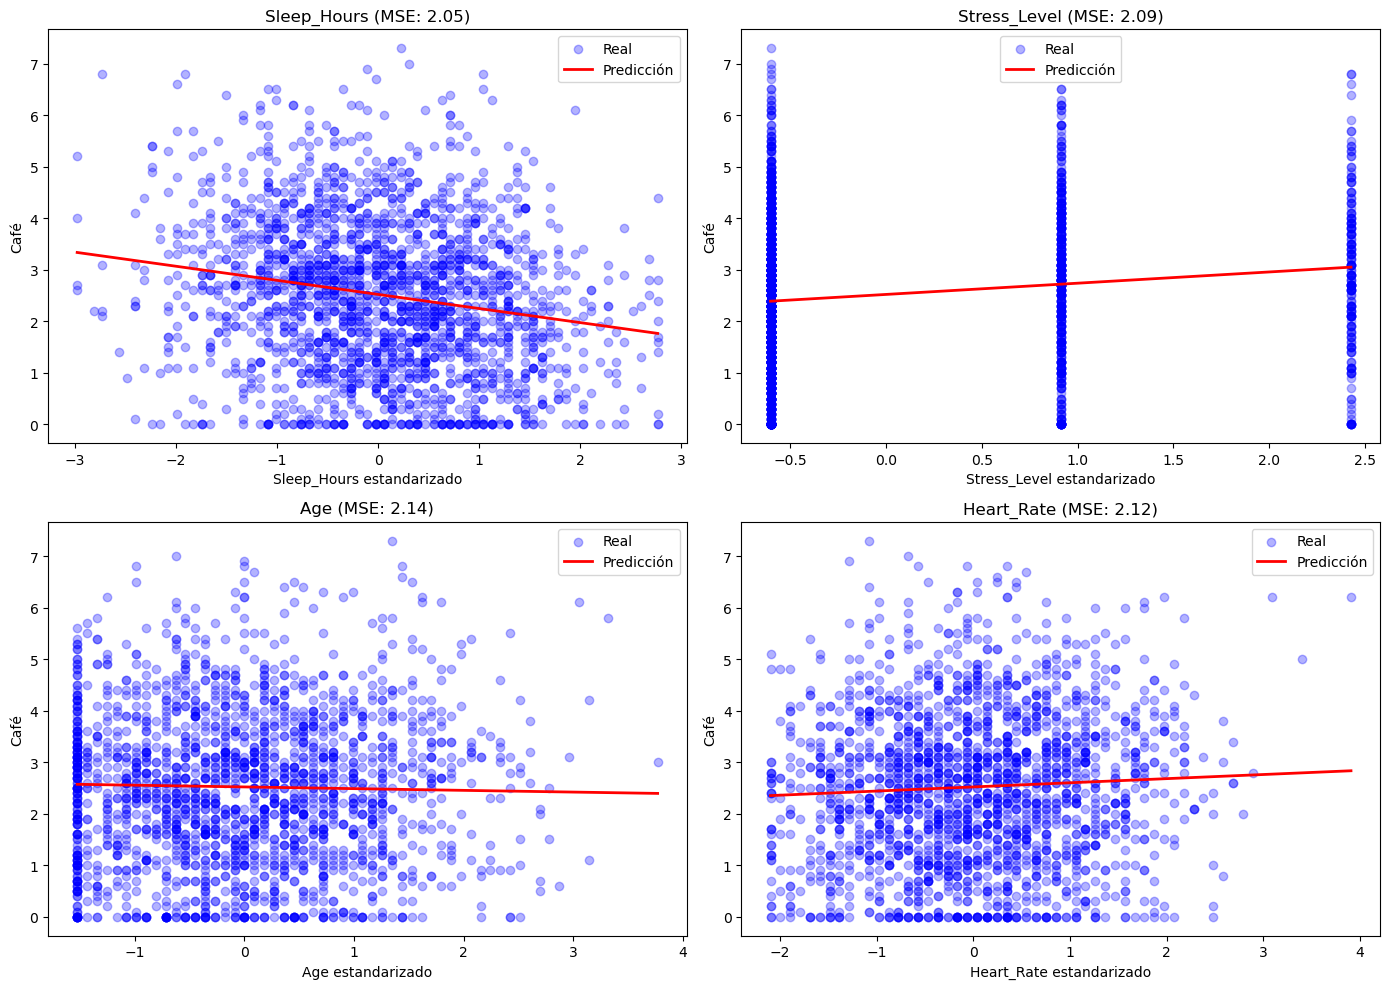


Tabla Comparativa Univariable (Ordenado por menor error):
       Variable       MSE        R2  Theta_Pendiente
0   Sleep_Hours  2.054821  0.037039        -0.273357
1  Stress_Level  2.091199  0.019991         0.217933
3    Heart_Rate  2.124852  0.004220         0.080272
2           Age  2.140991 -0.003343        -0.033365

(Usa esta tabla para responder qué variable es la mejor predictora en el informe)


In [40]:
# Ejecutamos la Modificación 1: Análisis Univariable.
# Probamos variables una a una para ver cuál predice mejor por sí sola.
print("\n" + "="*50)
print(" INICIO MODIFICACIÓN 1: ANÁLISIS UNIVARIABLE")
print("="*50)
    
vars_univariable = ['Sleep_Hours', 'Stress_Level', 'Age', 'Heart_Rate']
    
empty_ohe_train = pd.DataFrame(index=X_train_raw.index)
empty_ohe_test = pd.DataFrame(index=X_test_raw.index)
    
resultados_uni = []
    
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
    
for i, var in enumerate(vars_univariable):
    print(f"  -> Analizando variable: {var}...")
        
    X_train_uni = X_train_raw[[var]]
    X_test_uni  = X_test_raw[[var]]
        
    X_train_design_u, mu_u, sigma_u = preparar_matriz_final(X_train_uni, empty_ohe_train)
    X_test_design_u, _, _ = preparar_matriz_final(X_test_uni, empty_ohe_test, mu=mu_u, sigma=sigma_u)
        
    X_train_u_np = X_train_design_u.values.astype(float)
    X_test_u_np  = X_test_design_u.values.astype(float)
        
    theta_init_u = np.zeros((X_train_u_np.shape[1], 1))
    theta_u, _ = descenso_gradiente(X_train_u_np, y_train, theta_init_u, alpha, num_iters)
        
    y_pred_u = X_test_u_np.dot(theta_u)
        
    mse_u = MSE(y_test, y_pred_u)
    r2_u = calcular_r2(y_test, y_pred_u)
        
    resultados_uni.append({
        'Variable': var, 
        'MSE': mse_u, 
        'R2': r2_u,
        'Theta_Pendiente': theta_u[1][0] 
    })
        
    ax = axes[i]
    x_plot = X_test_u_np[:, 1]
        
    ax.scatter(x_plot, y_test, alpha=0.3, c='blue', label='Real')
        
    x_vals = np.linspace(x_plot.min(), x_plot.max(), 100)
    x_line_design = np.c_[np.ones(100), x_vals] 
    y_line = x_line_design.dot(theta_u)
        
    ax.plot(x_vals, y_line, color='red', lw=2, label='Predicción')
    ax.set_title(f"{var} (MSE: {mse_u:.2f})")
    ax.set_xlabel(f"{var} estandarizado")
    ax.set_ylabel("Café")
    ax.legend()
    
plt.tight_layout()
plt.show()
    
df_res_uni = pd.DataFrame(resultados_uni).sort_values(by='MSE')
print("\nTabla Comparativa Univariable (Ordenado por menor error):")
print(df_res_uni)
print("\n(Usa esta tabla para responder qué variable es la mejor predictora en el informe)")

In [41]:
    # Ejecutamos la Modificación 2: Selección de Atributos.
    # Comparamos si usar solo las mejores variables es más eficiente que usarlas todas.
    print("\n" + "="*50)
    print(" INICIO MODIFICACIÓN 2: SELECCIÓN DE ATRIBUTOS")
    print("="*50)
    
    resultados_ordenados = sorted(resultados_uni, key=lambda x: x['MSE'])
    
    mejor_variable = resultados_ordenados[0]['Variable']
    segunda_mejor  = resultados_ordenados[1]['Variable']
    
    print(f"  -> Mejores variables detectadas: {mejor_variable}, {segunda_mejor}")
    
    subsets = {
        'Solo Mejor Variable': [mejor_variable],
        'Top 2 Variables':     [mejor_variable, segunda_mejor],
        'Todas las Variables': cols_num + cols_ohe 
    }
    
    resultados_multi = []
    
    print("\n  -> Entrenando modelos con diferentes subconjuntos...")
    
    for nombre, cols in subsets.items():
        cols_n = [c for c in cols if c in X_train_raw.columns and c in cols_num]
        cols_c = [c for c in cols if c in X_train_raw.columns and c not in cols_num]
        
        X_train_sub = X_train_raw[cols_n + cols_c]
        X_test_sub  = X_test_raw[cols_n + cols_c]
        
        X_train_sub_num = X_train_sub[cols_n]
        X_train_sub_ohe = X_train_sub[cols_c]
        
        X_test_sub_num = X_test_sub[cols_n]
        X_test_sub_ohe = X_test_sub[cols_c]
        
        X_train_d, mu_sub, sigma_sub = preparar_matriz_final(X_train_sub_num, X_train_sub_ohe)
        X_test_d, _, _ = preparar_matriz_final(X_test_sub_num, X_test_sub_ohe, mu=mu_sub, sigma=sigma_sub)
        
        X_tr = X_train_d.values.astype(float)
        X_te = X_test_d.values.astype(float)
        
        theta_init = np.zeros((X_tr.shape[1], 1))
        theta_final, _ = descenso_gradiente(X_tr, y_train, theta_init, alpha, num_iters)
        
        y_pred_sub = X_te.dot(theta_final)
        mse_sub = MSE(y_test, y_pred_sub)
        
        resultados_multi.append({
            'Subconjunto': nombre,
            'Num_Variables': len(cols),
            'MSE': mse_sub
        })

    df_res_multi = pd.DataFrame(resultados_multi)
    
    mse_total = df_res_multi.loc[df_res_multi['Subconjunto'] == 'Todas las Variables', 'MSE'].values[0]
    
    df_res_multi['Mejora vs Todas (%)'] = (mse_total - df_res_multi['MSE']) / mse_total * 100
    
    print("\nTabla Comparativa de Selección de Atributos:")
    print(df_res_multi)


 INICIO MODIFICACIÓN 2: SELECCIÓN DE ATRIBUTOS
  -> Mejores variables detectadas: Sleep_Hours, Stress_Level

  -> Entrenando modelos con diferentes subconjuntos...

Tabla Comparativa de Selección de Atributos:
           Subconjunto  Num_Variables       MSE  Mejora vs Todas (%)
0  Solo Mejor Variable              1  2.054821            -0.007084
1      Top 2 Variables              2  2.054871            -0.009511
2  Todas las Variables             31  2.054675             0.000000
